# Supervised Machine Learning: Classification
# Water potability Classification

In [53]:
#Importing packages
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import zipfile
import sklearn as sk
import scipy.stats as ss
from scipy.stats import boxcox
from scipy.special import inv_boxcox
from sklearn.preprocessing import StandardScaler,MinMaxScaler, LabelEncoder, PolynomialFeatures
from sklearn.model_selection import StratifiedShuffleSplit, GridSearchCV, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay, recall_score, classification_report,precision_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE, RandomOverSampler
import pickle

#Reading Data
water_data=pd.read_csv('water_quality_potability.csv')
water_data.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,7.160466,195.712338,22636.785632,7.235746,336.794067,424.396711,14.376178,68.105888,3.991681,1
1,7.187738,193.202237,21263.028076,7.117409,333.997161,430.163405,14.206928,64.807703,3.957064,0
2,5.400302,140.739062,17266.593422,10.056852,328.358241,472.874073,11.256381,56.931906,4.824786,0
3,7.078913,196.886558,21539.185679,7.104867,335.223406,429.400333,14.344261,65.289765,3.909317,0
4,7.052283,194.971523,21659.468727,7.101790,335.669903,425.620822,14.100794,66.178504,3.989340,0


 ## Dataset and goal 
 * This dataset classifies the potability of water as safe(1) and unsafe(0) based on different observations of ph, solids, chloramines, Sulfate, conductivity,etc. 
 * The aim of the project is to create different ml models to predict the safeness of the water based on the given features of the data
 * While training the model 'precision' score is chosen to tune the params as we want high precision for water safeness as classifying an unsafe water wrongly as safe water can be very dangerous.

In [54]:
#check for duplicates
water_data.duplicated().sum()

0

In [55]:
#data info to check nulls
water_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               10000 non-null  float64
 1   Hardness         10000 non-null  float64
 2   Solids           10000 non-null  float64
 3   Chloramines      10000 non-null  float64
 4   Sulfate          10000 non-null  float64
 5   Conductivity     10000 non-null  float64
 6   Organic_carbon   10000 non-null  float64
 7   Trihalomethanes  10000 non-null  float64
 8   Turbidity        10000 non-null  float64
 9   Potability       10000 non-null  int64  
dtypes: float64(9), int64(1)
memory usage: 781.4 KB


In [56]:
#Class Balance
water_data['Potability'].value_counts(normalize=True)

1    0.5
0    0.5
Name: Potability, dtype: float64

**The Classes are balanced**
# Linear Features
## Features and classes


In [57]:
X= water_data.drop(columns='Potability')
y= water_data['Potability']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Hyper-parameter tuning

### Logistic regression

In [59]:
lr=LogisticRegression( multi_class='auto', solver='saga',max_iter=100000)
param_grid = {
    'C': [0.01,0.05, 0.1, 1,10,100],
    'penalty': ['l2']
}
search_lr = GridSearchCV(estimator=lr,cv=5, param_grid=param_grid,scoring='precision',n_jobs=-1)
search_lr.fit(X_train,y_train)
#search_lr.predict(X_train)
search_lr.best_params_, search_lr.best_score_

({'C': 0.05, 'penalty': 'l2'}, 0.8096364196822481)

{'accuracy': 0.8186666666666667, 'precision': 0.8091849935316947}
              precision    recall  f1-score   support

           0       0.83      0.80      0.82      1500
           1       0.81      0.83      0.82      1500

    accuracy                           0.82      3000
   macro avg       0.82      0.82      0.82      3000
weighted avg       0.82      0.82      0.82      3000



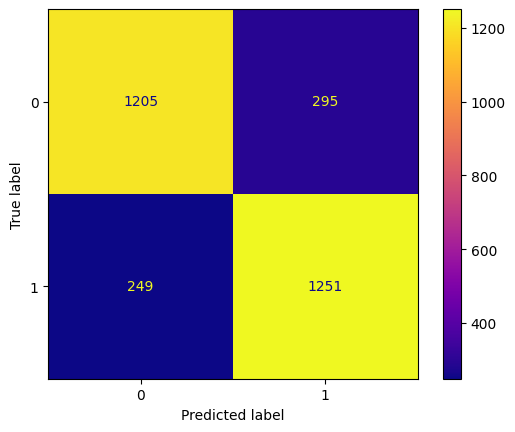

In [71]:
search_lr.best_estimator_.fit(X_train,y_train)
y_pred=search_lr.predict(X_test)
print({'accuracy':accuracy_score(y_true=y_test,y_pred=y_pred),'precision':precision_score(y_test,y_pred)})
print(classification_report(y_pred=y_pred,y_true=y_test))
cm=confusion_matrix(y_true=y_test,y_pred=y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='plasma')

### Random Forest Classifier

In [60]:
rf= RandomForestClassifier()
param_grid={'n_estimators': [100,200,400],
            'max_depth':[2,4,6,8,10,20,40,80],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [2, 4,6]}
search_rf =GridSearchCV(estimator=rf,cv=3,param_grid=param_grid,scoring='precision',n_jobs=-1)
search_rf.fit(X_train,y_train)
search_rf.predict(X_test)
search_rf.best_params_ ,search_rf.best_score_

({'max_depth': 20,
  'min_samples_leaf': 4,
  'min_samples_split': 10,
  'n_estimators': 400},
 0.8725239180190704)

{'accuracy': 0.8513333333333334, 'precision': 0.883551673944687}
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1500
           1       0.88      0.81      0.84      1500

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



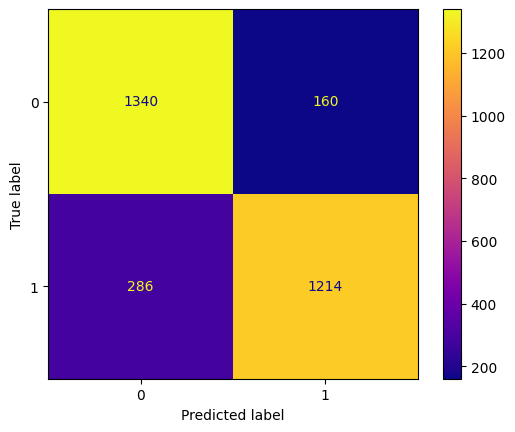

In [67]:
search_rf.best_estimator_.fit(X_train,y_train)
y_pred=search_rf.predict(X_test)
print({'accuracy':accuracy_score(y_true=y_test,y_pred=y_pred),'precision':precision_score(y_test,y_pred)})
print(classification_report(y_pred=y_pred,y_true=y_test))
cm=confusion_matrix(y_true=y_test,y_pred=y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='plasma')

### K-nearest neighbours

In [61]:
knn= KNeighborsClassifier()
param_grid={'n_neighbors': [1, 3, 5, 7, 9, 11]}
search_knn =GridSearchCV(estimator=knn,cv=3,param_grid=param_grid,scoring='precision',n_jobs=-1)
search_knn.fit(X_train, y_train)
search_knn.best_params_, search_knn.best_score_

({'n_neighbors': 11}, 0.8707675581661416)

{'accuracy': 0.8473333333333334, 'precision': 0.8780841799709724}
              precision    recall  f1-score   support

           0       0.82      0.89      0.85      1500
           1       0.88      0.81      0.84      1500

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



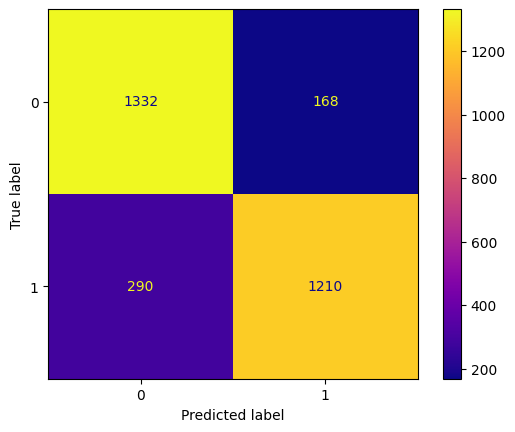

In [69]:
search_knn.best_estimator_.fit(X_train,y_train)
y_pred=search_knn.predict(X_test)
print({'accuracy':accuracy_score(y_true=y_test,y_pred=y_pred),'precision':precision_score(y_test,y_pred)})
print(classification_report(y_pred=y_pred,y_true=y_test))
cm=confusion_matrix(y_true=y_test,y_pred=y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='plasma')

### Gradient Boosting Classifier

In [62]:
gbc= GradientBoostingClassifier()
param_grid = {'n_estimators': [100,200,300],
            'max_depth':[2,10,40,80],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [2, 4,6],         
    'learning_rate': [ 0.1,0.5,1],                    
    'subsample': [0.4,0.6, 0.8, 1.0],                
}
search_gb= GridSearchCV(gbc,param_grid=param_grid,cv=3,scoring='precision',n_jobs=-1)
search_gb.fit(X_train,y_train)
search_gb.best_params_, search_gb.best_score_

({'learning_rate': 0.1,
  'max_depth': 40,
  'min_samples_leaf': 2,
  'min_samples_split': 5,
  'n_estimators': 200,
  'subsample': 0.8},
 0.8638976139089568)

{'accuracy': 0.843, 'precision': 0.859538784067086}
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1500
           1       0.86      0.82      0.84      1500

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



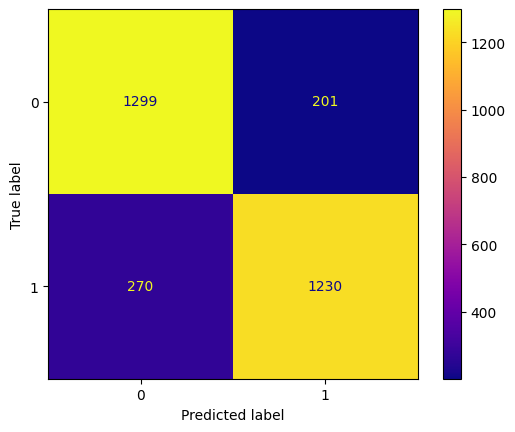

In [70]:
search_gb.best_estimator_.fit(X_train,y_train)
y_pred=search_gb.predict(X_test)
print({'accuracy':accuracy_score(y_true=y_test,y_pred=y_pred),'precision':precision_score(y_test,y_pred)})
print(classification_report(y_pred=y_pred,y_true=y_test))
cm=confusion_matrix(y_true=y_test,y_pred=y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='plasma')

### SVM

In [63]:
sv= SVC(probability=True)
param_grid={'kernel':['linear', 'rbf'],}
search_sv =GridSearchCV(estimator=sv,cv=3,param_grid=param_grid,scoring='precision',n_jobs=-1)
search_sv.fit(X_train,y_train)
search_sv.predict(X_test)
search_sv.best_params_

{'kernel': 'rbf'}

In [64]:
search_sv.best_score_

0.871091762056218

{'accuracy': 0.852, 'precision': 0.8787661406025825}
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1500
           1       0.88      0.82      0.85      1500

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



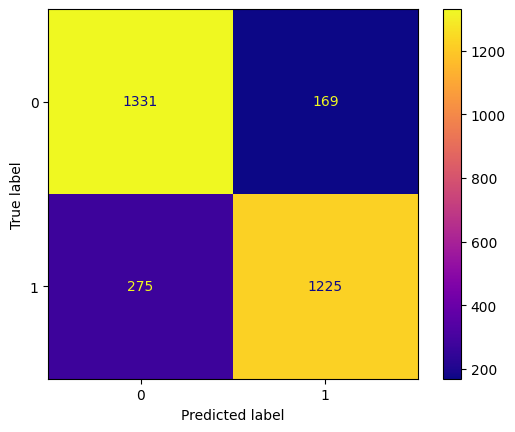

In [73]:
search_sv.best_estimator_.fit(X_train,y_train)
y_pred=search_sv.predict(X_test)
print({'accuracy':accuracy_score(y_true=y_test,y_pred=y_pred),'precision':precision_score(y_test,y_pred)})
print(classification_report(y_pred=y_pred,y_true=y_test))
cm=confusion_matrix(y_true=y_test,y_pred=y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='plasma')

## Voting Classifier

{'accuracy': 0.8546666666666667, 'precision': 0.8827338129496403}
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1500
           1       0.88      0.82      0.85      1500

    accuracy                           0.85      3000
   macro avg       0.86      0.85      0.85      3000
weighted avg       0.86      0.85      0.85      3000



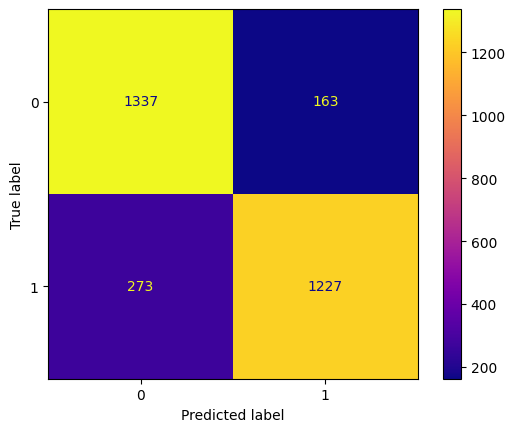

In [76]:
#Linear
knn=KNeighborsClassifier(n_neighbors=11)
lr= LogisticRegression(penalty='l2',C=0.05,max_iter=100000)
rf= RandomForestClassifier(n_estimators=400,min_samples_leaf=4,max_depth=20,min_samples_split=2)
gbc= GradientBoostingClassifier(learning_rate=0.1,subsample=0.8,n_estimators=200,min_samples_split=5,max_depth=40,min_samples_leaf=2)
sv= SVC(kernel='rbf',probability=True)
vc=VotingClassifier(estimators=[('lr',lr),('knn',knn),('rf',rf),('gbc', gbc),('sv',sv)],voting='hard',n_jobs=-1)
vc.fit(X_train,y_train)
y_pred=vc.predict(X_test)
print({'accuracy':accuracy_score(y_true=y_test,y_pred=y_pred),'precision':precision_score(y_test,y_pred)})
print(classification_report(y_pred=y_pred,y_true=y_test))
cm=confusion_matrix(y_true=y_test,y_pred=y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='plasma')

## Stacking

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1500
           1       0.88      0.83      0.85      1500

    accuracy                           0.86      3000
   macro avg       0.86      0.86      0.86      3000
weighted avg       0.86      0.86      0.86      3000

{'accuracy': 0.8586666666666667, 'precision': 0.8842857142857142}


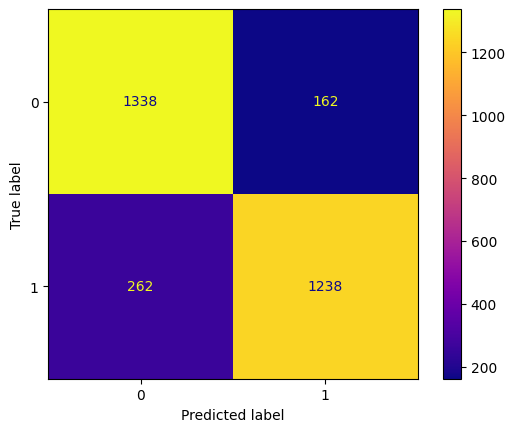

In [77]:

St= StackingClassifier(estimators=[('lr',lr),('knn',knn),('rf',rf),('gbc', gbc),('sv',sv)],final_estimator=LogisticRegression(),n_jobs=-1)
St.fit(X_train,y_train)
y_pred=St.predict(X_test)
print(classification_report(y_true=y_test,y_pred=y_pred))
print({'accuracy':accuracy_score(y_true=y_test,y_pred=y_pred),'precision':precision_score(y_test,y_pred)})
cm=confusion_matrix(y_true=y_test,y_pred=y_pred)
ConfusionMatrixDisplay(cm).plot(cmap='plasma')

## Conclusion:
* Random forest,SVM and Knn models resulted the best among the individual models with tuned hyperparameters.
* Stacking of various model results in the best precision of 89 percent with a close competition from the voting classifier. 
* The precision is likely increase with more data.
* The models needs to be evaluated further with more advanced methods and data due to very high precision requirement of this case